## Exam 2 Part 1

 #### Madison Ward

 I will be doing the SQL on a different notebook since the outputs have to be cleared. I will answer questions 3 and 4 on here.

 1a. Got it displayed! Himalayas has majority of the 8000m mountains.

In [24]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/List_of_mountains_by_elevation"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()

df = [t for t in pd.read_html(response.text) if "Everest" in t.to_string()][0]

df.columns = df.columns.get_level_values(0);
df = df.rename(columns={"Mountain": "Mountain", "Metres": "Meters", "Range": "Range"})
df = df[["Mountain", "Meters", "Feet", "Range"]]

display(df)

/tmp/ipykernel_1946/3310466334.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = [t for t in pd.read_html(response.text) if "Everest" in t.to_string()][0]


,Mountain,Meters,Feet,Range
0,Mount Everest,8848,29029,Himalayas
1,K2,8611,28251,Karakoram
2,Kangchenjunga,8586,28169,Himalayas
3,Lhotse,8516,27940,Himalayas
4,Makalu,8485,27838,Himalayas
5,Cho Oyu,8188,26864,Himalayas
6,Dhaulagiri,8167,26795,Himalayas
7,Manaslu,8163,26781,Himalayas
8,Nanga Parbat,8126,26660,Himalayas
9,Annapurna,8091,26545,Himalayas


1b. Bar chart confirming my observation. 10 of the 14 mountains are in the Himalayas.

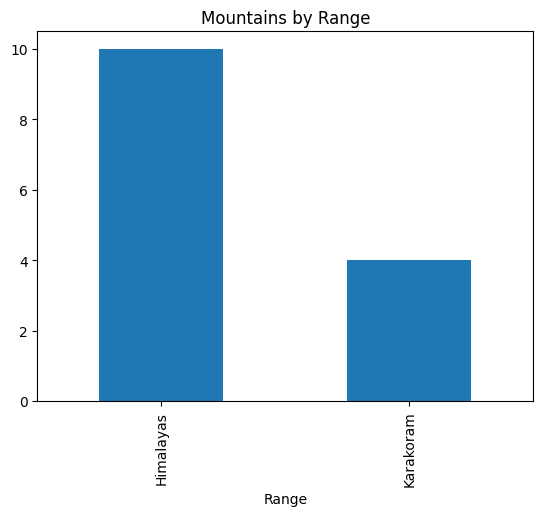

In [20]:
df["Range"].value_counts().plot(kind="bar")
plt.title("Mountains by Range")
plt.show()

1c. Box plot. Shows the highest (29,029 ft) and the lowest (26,335 ft) clearly, and that the data is most dense between 26500 ft and 27000.

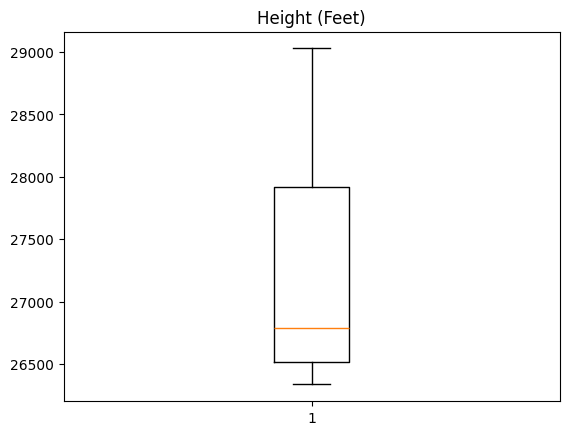

In [21]:
plt.boxplot(df["Feet"])
plt.title("Height (Feet)")
plt.show()

1d. Stats: Mean at 27,178.07 feet adds up. SD of 879.43, not a huge variation! The five number summary shows that the mountain Shishapangma at 26335 ft is the minimum, 25% of the mountains are below 26518ft, the median is 26788ft, 75% are below 27914ft, and the tallest is 29029ft at Mount Everest.

In [22]:
print("Mean:", df["Feet"].mean())
print("Std:", df["Feet"].std())
print("Five-number summary:\n", df["Feet"].describe()[["min","25%","50%","75%","max"]])

Mean: 27178.071428571428
Std: 879.4310629637179
Five-number summary:
 min    26335.00
25%    26518.75
50%    26788.00
75%    27914.50
max    29029.00
Name: Feet, dtype: float64


1e. Mean and median by range. The Himalayas has higher of both, with 27295.6 mean and 26829.5 median. Karakoram's values are about the same distance from each other with mean 26884.35 and med of 26462.

In [23]:
print("\nMean & Median by Range:\n", df.groupby("Range")["Feet"].agg(["mean","median"]))


Mean & Median by Range:
                mean   median
Range                       
Himalayas  27295.60  26829.5
Karakoram  26884.25  26462.0


## 2a-2c on part 2.

3a. This exam took me roughly 3 hours

3b. The hardest part wasn't even one of the questions, it was figuring out how to make BigQuery and SQL work for me again. The easiest topic was creating the graphs and stats on part 1b-1e.

3c. I am most excited to use scraping again. I still need some work on it, but it seems like it is very useful.

4a. Queries

how to get 5 number summary on python
- You can get a five-number summary in Python in a few simple ways using pandas. ✅ Method 1 (Best / simplest): describe()
df["Feet"].describe()[["min", "25%", "50%", "75%", "max"]]

in the payment types, what is PRcard and Pcard
- In the Chicago taxi dataset, the payment_type field uses abbreviations that can be a bit confusing. Here’s what those mean:

- Pcard = Procurement Card
→ A business/government-issued credit card used for official expenses (not a personal card)

- PRcard = Prepaid Card
→ A card loaded with a fixed amount of money in advance (like a gift card or transit card)

i have the above average fares showing, how can i show the average payment with it
- Got it—you want to show the fares themselves, and also display the overall average fare alongside them. Best way to do that is with a window function.

✅ Show fares > average (with the average included)
*code for part 2c*

4d. I attest that the resources above were the only ones utilized in completing the exam and the work included is my own and no one else from the course.